In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [11]:
df = pd.read_csv('/content/Walmart_Sales (1).csv')

In [12]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [14]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [15]:
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month

df.drop("Date",axis=1,inplace=True)

In [16]:
df.columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'Year', 'Month'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Year          6435 non-null   int32  
 8   Month         6435 non-null   int32  
dtypes: float64(5), int32(2), int64(2)
memory usage: 402.3 KB


In [18]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3


In [19]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000


<Axes: >

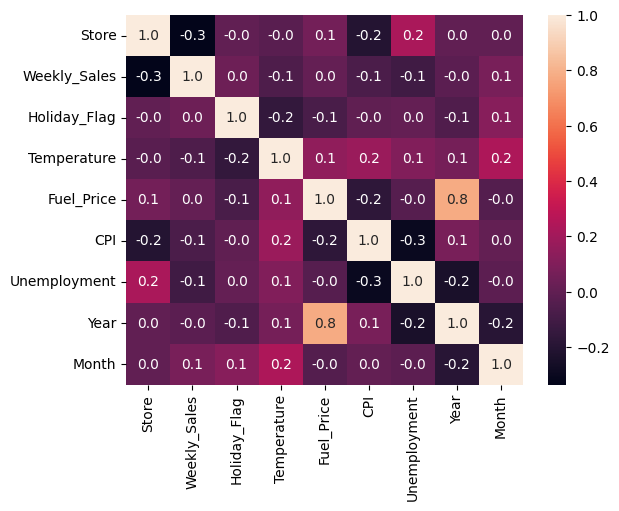

In [20]:
data = df.corr()
sns.heatmap(data=data,annot=True,fmt='.1f')

In [21]:
df.shape

(6435, 9)

In [22]:
df.nunique()

,0
Store,45
Weekly_Sales,6435
Holiday_Flag,2
Temperature,3528
Fuel_Price,892
CPI,2145
Unemployment,349
Year,3
Month,12


In [23]:
unemp_sales = df.groupby('Store').agg(
    total_unemp_rate = ('Unemployment','mean'),
    total_weekly_sales = ('Weekly_Sales','sum')
)

In [24]:
print(unemp_sales)

       total_unemp_rate  total_weekly_sales
Store                                      
1              7.610420        2.224028e+08
2              7.623846        2.753824e+08
3              7.176986        5.758674e+07
4              5.964692        2.995440e+08
5              6.295406        4.547569e+07
6              6.606902        2.237561e+08
7              8.585734        8.159828e+07
8              6.091846        1.299512e+08
9              6.099881        7.778922e+07
10             8.362965        2.716177e+08
11             7.176986        1.939628e+08
12            13.116483        1.442872e+08
13             7.001825        2.865177e+08
14             8.648748        2.889999e+08
15             7.996252        8.913368e+07
16             6.477993        7.425243e+07
17             6.549406        1.277821e+08
18             8.838301        1.551147e+08
19             7.996252        2.066349e+08
20             7.371413        3.013978e+08
21             7.623846        1

In [25]:
unemp_sales.sort_values(by='total_weekly_sales',ascending=False)

,total_unemp_rate,total_weekly_sales
Store,,
20,7.371413,3.013978e+08
4,5.964692,2.995440e+08
14,8.648748,2.889999e+08
13,7.001825,2.865177e+08
2,7.623846,2.753824e+08
10,8.362965,2.716177e+08
27,8.001748,2.538559e+08
6,6.606902,2.237561e+08
1,7.610420,2.224028e+08


In [26]:
top_store = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

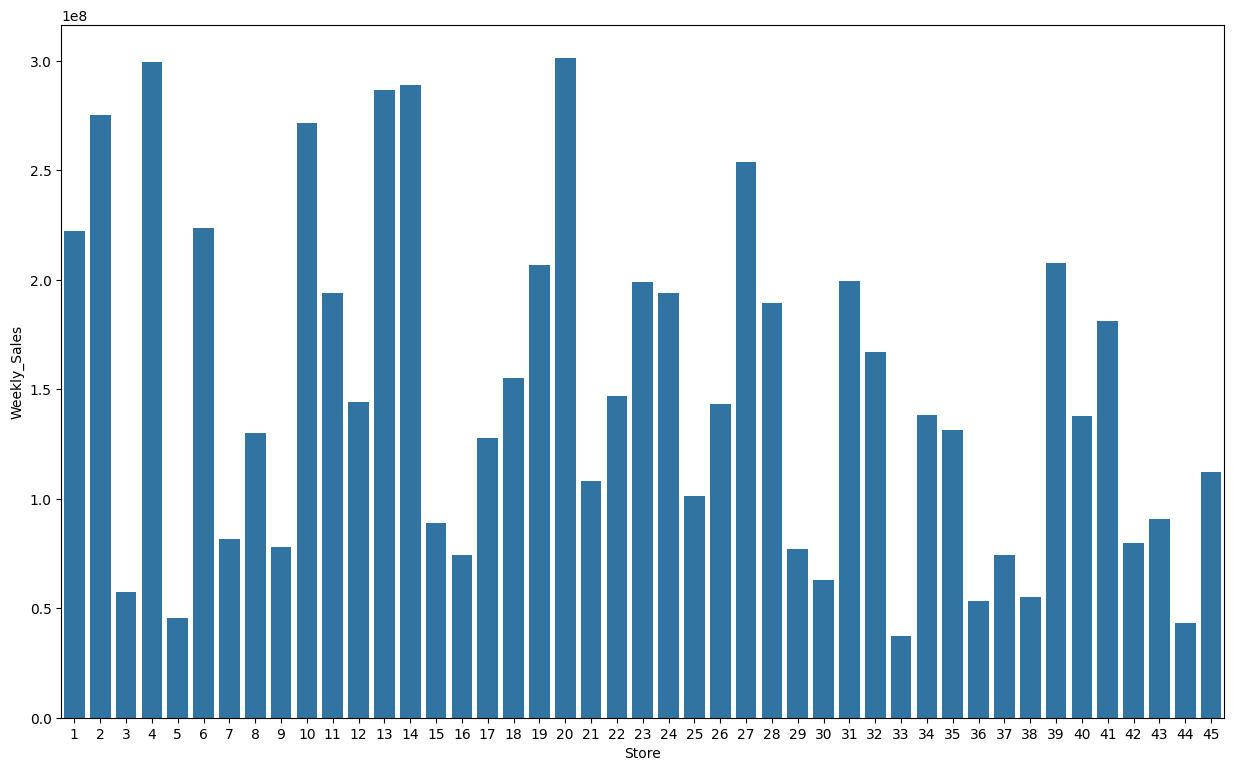

In [27]:
plt.figure(figsize=(15,9))
sns.barplot(top_store)

In [28]:
high_fuel_price = df.groupby('Store')['Fuel_Price'].mean().sort_values(ascending=False)

Text(0.5, 1.0, 'Average price of fuel at each store')

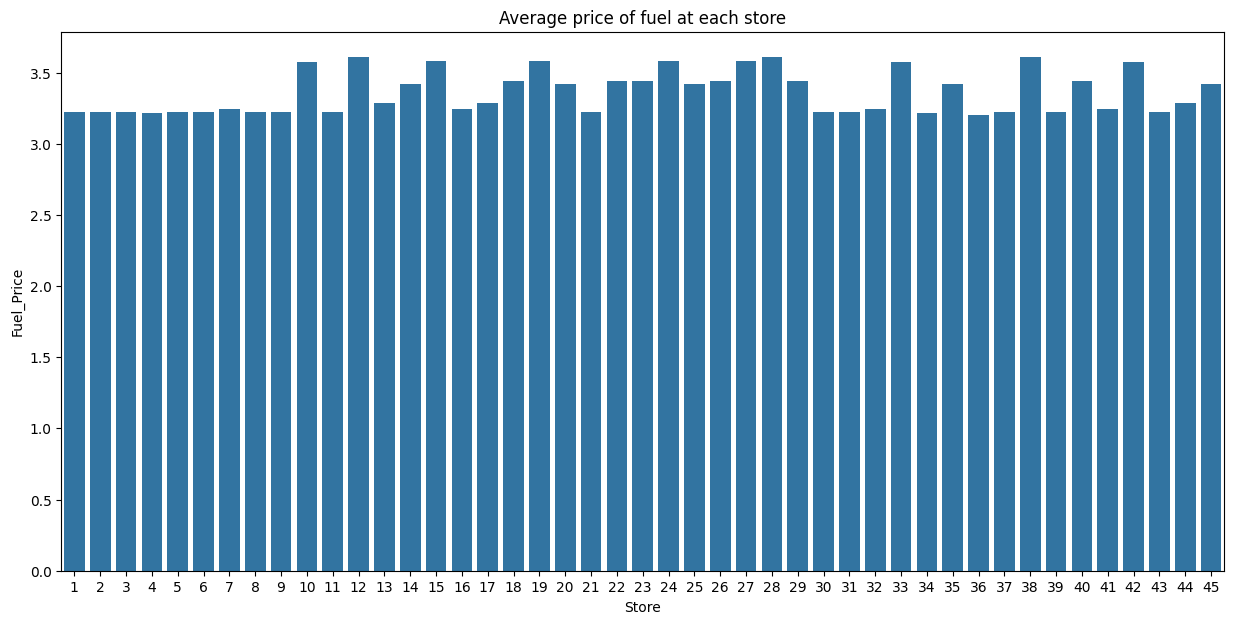

In [29]:
plt.figure(figsize=(15,7))
sns.barplot(high_fuel_price)
plt.title('Average price of fuel at each store')

In [30]:
df.groupby('Holiday_Flag')['Fuel_Price'].mean()

,Fuel_Price
Holiday_Flag,
0,3.368467
1,3.227464


In [31]:
x = df.drop('Weekly_Sales',axis=1)
y = df['Weekly_Sales']


In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [ ]:
x_train.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
1033,8,0,75.32,2.582,214.878556,6.315,2010,9
915,7,0,20.70,3.372,192.058484,8.818,2011,3
5903,42,0,61.24,3.130,126.546161,9.003,2010,11
2083,15,0,69.19,3.906,136.213613,7.806,2011,8
5943,42,0,87.40,3.743,129.240581,8.257,2011,8


In [33]:
x_test.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
2436,18,0,42.39,2.805,131.784000,9.202,2010,3
3361,24,0,68.88,3.964,135.265267,8.212,2011,6
233,2,0,65.87,3.372,217.325182,7.441,2011,10
3667,26,0,40.08,3.570,136.461806,7.598,2011,11
5011,36,0,59.56,2.701,209.980321,8.554,2010,3


In [34]:
y_train.head()

,Weekly_Sales
1033,836707.85
915,558963.83
5903,588592.61
2083,605413.17
5943,526641.23


In [35]:
y_test.head()

,Weekly_Sales
2436,1138800.32
3361,1304850.67
233,1769296.25
3667,1077640.13
5011,428851.99


In [36]:
lr = LinearRegression()
lr.fit(x_train,y_train)

y_pred_lr = lr.predict(x_test)

In [37]:
print("MAE:",mean_absolute_error(y_test,y_pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print("R2 Score:",r2_score(y_test,y_pred_lr))

MAE: 432293.58773906546
RMSE: 521321.81390435324
R2 Score: 0.15637875886838504


In [38]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [39]:
print("MAE:",mean_absolute_error(y_test,y_pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print("R2 Score:",r2_score(y_test,y_pred_rf))

MAE: 72529.5516933955
RMSE: 139618.27150866383
R2 Score: 0.9394909652724325


In [42]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":importance
}).sort_values(by = "Importance",ascending = False)

print(feature_importance)

        Feature  Importance
0         Store    0.662161
4           CPI    0.161970
5  Unemployment    0.105902
7         Month    0.030000
2   Temperature    0.018863
3    Fuel_Price    0.015411
1  Holiday_Flag    0.004732
6          Year    0.000961


In [40]:
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

In [41]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 67515.64273844211
RMSE: 118436.99982666943
R2 Score: 0.956457786206163
